In [4]:
!mamba install pandas numpy matplotlib seaborn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.470 seconds
All requested packages already installed.


In [5]:
import pandas as pd
import numpy as np

# 1. Load the data (no special delimiter needed since commas worked)
df = pd.read_csv('results.csv')

# 2. Filter for completed tests if the 'bailedOut' column exists 
# (Scroll right in your preview to check, or let Python handle it here)
if 'bailedOut' in df.columns:
    df = df[df['bailedOut'] == False]

# 3. Clean up the timestamps if the column is there
if 'timestamp' in df.columns:
    df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
    df = df.sort_values('date').reset_index(drop=True)
    df['year'] = df['date'].dt.year

# 4. Create a test counter to track your timeline
df['test_number'] = np.arange(1, len(df) + 1)

# Print your baseline stats
print(f"Total completed tests: {len(df)}")
print(f"Your all-time highest WPM: {df['wpm'].max()}")
print(f"Your lifetime average accuracy: {df['acc'].mean():.1f}%")

Total completed tests: 980
Your all-time highest WPM: 193.98
Your lifetime average accuracy: 97.9%


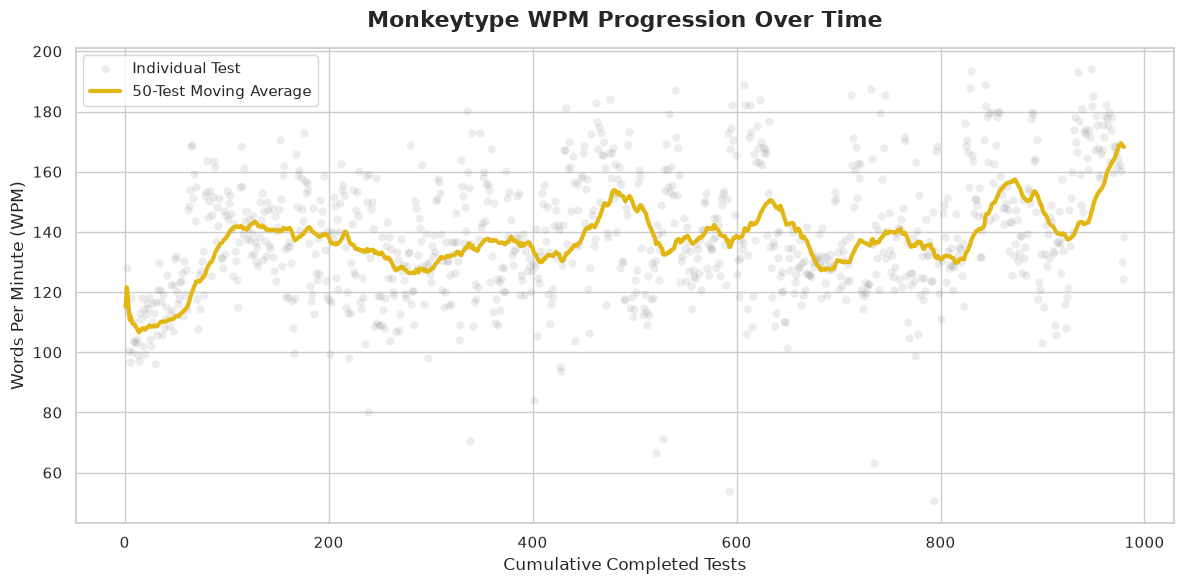

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_theme(style="whitegrid")

# Create a figure
plt.figure(figsize=(12, 6))

# Plot your individual test WPM as scattered dots to show the spread
sns.scatterplot(data=df, x='test_number', y='wpm', alpha=0.15, color='gray', label='Individual Test')

# Plot a rolling average line to smooth out the noise and show the real trend
# This takes the average of every 50 tests chronologically
df['wpm_rolling'] = df['wpm'].rolling(window=50, min_periods=1).mean()
sns.lineplot(data=df, x='test_number', y='wpm_rolling', color='#e2b714', linewidth=3, label='50-Test Moving Average')

# Labels and titles
plt.title('Monkeytype WPM Progression Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Cumulative Completed Tests', fontsize=12)
plt.ylabel('Words Per Minute (WPM)', fontsize=12)
plt.legend(frameon=True)

# Show the chart
plt.tight_layout()
plt.show()

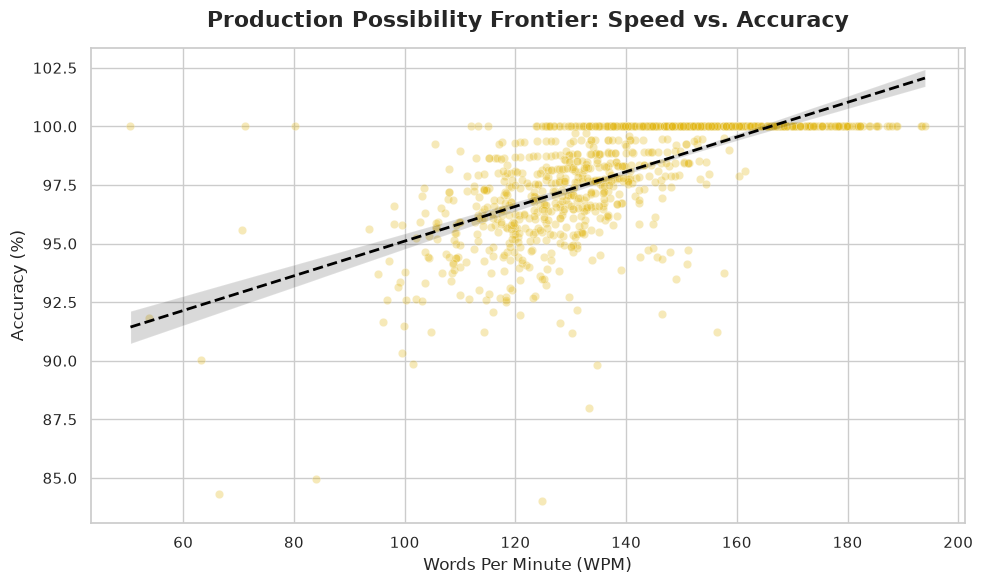

In [7]:
plt.figure(figsize=(10, 6))

# Scatter plot of Speed vs Accuracy
sns.scatterplot(data=df, x='wpm', y='acc', alpha=0.3, color='#e2b714')

# Add a trend line to see if higher speeds generally mean lower accuracy
sns.regplot(data=df, x='wpm', y='acc', scatter=False, color='black', line_kws={"linewidth": 2, "linestyle": "--"})

plt.title('Production Possibility Frontier: Speed vs. Accuracy', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Words Per Minute (WPM)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
import statsmodels.api as sm

# Define our variables
# Dependent variable (Y): Accuracy
# Independent variable (X): WPM
Y = df['acc']
X = df['wpm']

# Add a constant term (the intercept beta_0)
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(Y, X).fit()

# Print the regression results table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    acc   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     746.9
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          1.23e-122
Time:                        20:39:22   Log-Likelihood:                -1950.1
No. Observations:                 980   AIC:                             3904.
Df Residuals:                     978   BIC:                             3914.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         87.7013      0.379    231.331      0.0

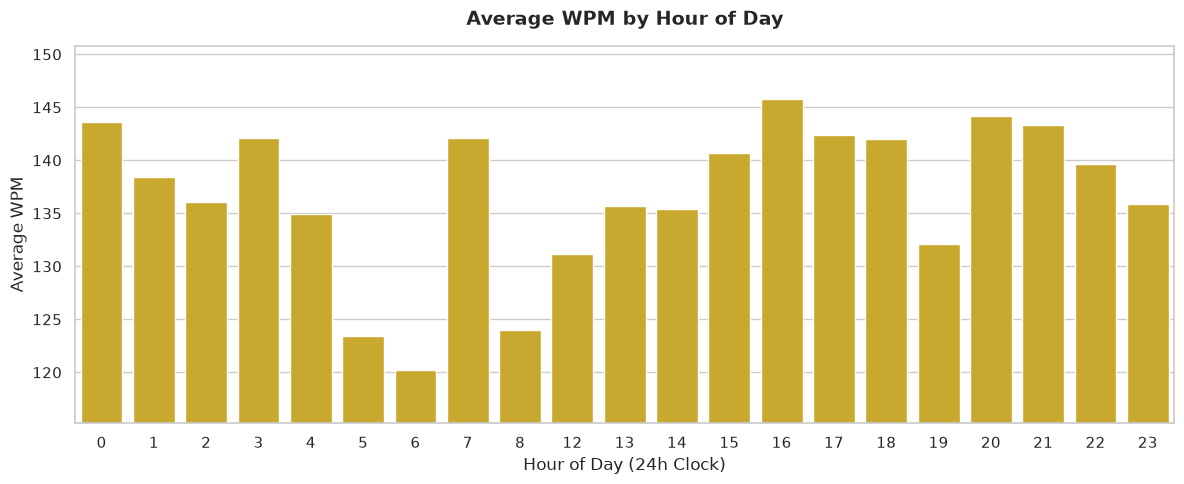

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the missing hour column from your date data
df['hour'] = df['date'].dt.hour

# Set up the figure size
plt.figure(figsize=(12, 5))

# Group by hour and get average WPM
hourly_wpm = df.groupby('hour')['wpm'].mean().reset_index()

# Generate the bar plot
sns.barplot(data=hourly_wpm, x='hour', y='wpm', color='#e2b714')

# Labels and styling
plt.title('Average WPM by Hour of Day', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (24h Clock)', fontsize=12)
plt.ylabel('Average WPM', fontsize=12)

# Zoom in the y-axis slightly to see the performance differences clearly
plt.ylim(hourly_wpm['wpm'].min() - 5, hourly_wpm['wpm'].max() + 5)

plt.tight_layout()
plt.show()

In [10]:
# Dependent variable
Y = df['acc']

# Independent variables: Speed AND Cumulative Experience
X = df[['wpm', 'test_number']]
X = sm.add_constant(X)

# Fit the multiple regression model
multi_model = sm.OLS(Y, X).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    acc   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     529.1
Date:                Sat, 25 Jul 2026   Prob (F-statistic):          2.08e-156
Time:                        20:39:22   Log-Likelihood:                -1868.6
No. Observations:                 980   AIC:                             3743.
Df Residuals:                     977   BIC:                             3758.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          87.5726      0.349    250.811      

In [11]:
plt.savefig('wpm_progression_trend.png', dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>